<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/%E6%A0%AA%E4%BE%A1%E8%AA%AD%E3%81%BF%E5%8F%96%E3%82%8AAI_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "AAPL"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# Handle potential MultiIndex from yfinance to ensure df['Close'] is a Series
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(level=1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy() # Use .copy() to avoid SettingWithCopyWarning
df.columns = ['Close', 'High', 'Low', 'Volume'] # Ensure column names are simple strings
df.dropna(inplace=True)

# ======================
# 特徴量作成
# ======================

# SMA
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_25'] = df['Close'].rolling(25).mean()
df['SMA_DIFF'] = df['SMA_5'] - df['SMA_25']
df['SMA_RATIO'] = df['SMA_5'] / df['SMA_25']

# Target
future_max = df['Close'].shift(-1).rolling(3).max()
df['Target'] = ((future_max / df['Close'] - 1) > 0.0075).astype(int)

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD'] = ema12 - ema26
df['Signal_Line'] = df['MACD'].ewm(span=9).mean()
df['MACD_Hist'] = df['MACD'] - df['Signal_Line']

# ATR
tr = pd.concat([
    df['High'] - df['Low'],
    abs(df['High'] - df['Close'].shift()),
    abs(df['Low'] - df['Close'].shift())
], axis=1).max(axis=1)

df['ATR'] = tr.rolling(14).mean()

# ボリンジャー
# Ensure ma and std are Series by using .squeeze() if they result in single-column DataFrames
ma = df['Close'].rolling(20).mean().squeeze()
std = df['Close'].rolling(20).std().squeeze()

df['Upper_BB'] = ma + 2 * std
df['Lower_BB'] = ma - 2 * std
df['BB_Width'] = (df['Upper_BB'] - df['Lower_BB']) / ma

# ラグ
for lag in range(1, 6):
    df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)

# 最後にNaN削除
df.dropna(inplace=True)

print("セル1完了:", df.shape)

/tmp/ipykernel_5520/2141199403.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

セル1完了: (1561, 22)


In [3]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width'
]

# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])

使用特徴量数: 17
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [4]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Xとy
X = df[features].copy()
y = df['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1561, 17)
y shape: (1561,)
Target分布:
Target
0    0.516336
1    0.483664
Name: proportion, dtype: float64


In [5]:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1561, 17)


In [6]:
# ======================
# 時系列分割
# ======================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train期間:", X_train.index.min(), "→", X_train.index.max())
print("Test期間 :", X_test.index.min(), "→", X_test.index.max())

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train期間: 2020-02-06 00:00:00 → 2025-01-23 00:00:00
Test期間 : 2025-01-24 00:00:00 → 2026-04-23 00:00:00
Train size: (1248, 17)
Test size : (313, 17)


In [7]:
# ======================
# SMOTE（訓練データのみ）
# ======================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE: Target
1    631
0    617
Name: count, dtype: int64
After SMOTE:
Target
0    631
1    631
Name: count, dtype: int64


In [9]:
# ======================
# RandomForest チューニング
# ======================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# モデル定義
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# パラメータ範囲
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# チューニング
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 最初は軽めでOK（後で増やせる）
    scoring='f1',             # 不均衡データ向け
    cv=3,                     # 時系列じゃない簡易CV（後で改善）
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ使う）
random_search_rf.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_rf_tuned = random_search_rf.best_estimator_

print("Best params:", random_search_rf.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 180}


In [10]:
# ======================
# XGBoost チューニング
# ======================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# モデル定義
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# パラメータ範囲
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

# チューニング
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,          # 最初は軽め
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ）
random_search_xgb.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_xgb_tuned = random_search_xgb.best_estimator_

print("Best params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.7531707499015159), 'gamma': np.float64(0.4858560476945519), 'learning_rate': np.float64(0.1797827648532168), 'max_depth': 7, 'n_estimators': 317, 'reg_alpha': np.float64(0.11799245987447787), 'reg_lambda': np.float64(0.884102484141986), 'subsample': np.float64(0.6161734358153725)}


In [11]:
# ======================
# 予測確率の取得
# ======================

# RandomForest
proba_class1_rf = model_rf_tuned.predict_proba(X_test)[:, 1]

# XGBoost
proba_class1_xgb = model_xgb_tuned.predict_proba(X_test)[:, 1]

# 確認
print("RF proba shape:", proba_class1_rf.shape)
print("XGB proba shape:", proba_class1_xgb.shape)

RF proba shape: (313,)
XGB proba shape: (313,)


In [12]:
# ======================
# 戦略A・Bの定義
# ======================

# 閾値（あとで調整可能）
threshold = 0.6

# --- 戦略A：AND条件（両モデルが強気） ---
strategy_A = (
    (proba_class1_rf > threshold) &
    (proba_class1_xgb > threshold)
).astype(int)

# --- 戦略B：XGBoost重視 ---
strategy_B = (
    (proba_class1_xgb > threshold)
).astype(int)

# 確認
print("Strategy A trades:", strategy_A.sum())
print("Strategy B trades:", strategy_B.sum())

Strategy A trades: 14
Strategy B trades: 92


In [14]:
# ======================
# バックテスト関数（統一版）
# ======================

def run_backtest(df, X_test, signals, initial_balance=100000, risk_per_trade=0.02):

    # --- テスト期間のデータだけ使う ---
    df_bt = df.loc[X_test.index].copy()

    # --- 必須列チェック ---
    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # signalsも同じindexに揃える
    signals = signals.loc[df_bt.index]

    # --- 初期化 ---
    balance = initial_balance
    equity_curve = []
    position = 0
    entry_price = 0
    trade_count = 0
    win_count = 0

    for i in range(len(df_bt) - 1):
        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        signal = signals.iloc[i]

        # ======================
        # エントリー
        # ======================
        if position == 0 and signal == 1:

            # ATR-based position sizing
            atr = row['ATR']
            if pd.isna(atr) or atr == 0:
                continue

            risk_amount = balance * risk_per_trade
            stop_loss_distance = atr * 2

            position_size = risk_amount / stop_loss_distance

            entry_price = next_row['Close']
            position = position_size
            trade_count += 1

        # ======================
        # ポジション保有中
        # ======================
        elif position > 0:

            current_price = next_row['Close']

            # ストップロス
            stop_price = entry_price - (row['ATR'] * 2)

            # 利確（リスクリワード 1:2）
            take_profit_price = entry_price + (row['ATR'] * 4)

            exit_flag = False

            if current_price <= stop_price:
                exit_flag = True
            elif current_price >= take_profit_price:
                exit_flag = True

            if exit_flag:
                pnl = (current_price - entry_price) * position
                balance += pnl

                if pnl > 0:
                    win_count += 1

                position = 0

        equity_curve.append(balance)

    # --- 最後のポジション強制決済 ---
    if position > 0:
        final_price = df_bt.iloc[-1]['Close']
        pnl = (final_price - entry_price) * position
        balance += pnl

        if pnl > 0:
            win_count += 1

    # --- 結果まとめ ---
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    results = {
        'Final Balance': balance,
        'Total Return (%)': total_return,
        'Total Trades': trade_count,
        'Win Rate (%)': win_rate
    }

    return results, equity_curve

In [15]:
# ======================
# バックテスト実行
# ======================

import pandas as pd

# signalsをSeriesに変換（超重要）
signals_A = pd.Series(strategy_A, index=X_test.index)
signals_B = pd.Series(strategy_B, index=X_test.index)

# --- 戦略A ---
results_A, equity_A = run_backtest(df, X_test, signals_A)

# --- 戦略B ---
results_B, equity_B = run_backtest(df, X_test, signals_B)

# 結果表示
print("===== Strategy A =====")
for k, v in results_A.items():
    print(f"{k}: {v}")

print("\n===== Strategy B =====")
for k, v in results_B.items():
    print(f"{k}: {v}")

===== Strategy A =====
Final Balance: 104832.97046934256
Total Return (%): 4.832970469342568
Total Trades: 5
Win Rate (%): 40.0

===== Strategy B =====
Final Balance: 116981.79038303423
Total Return (%): 16.981790383034223
Total Trades: 14
Win Rate (%): 50.0


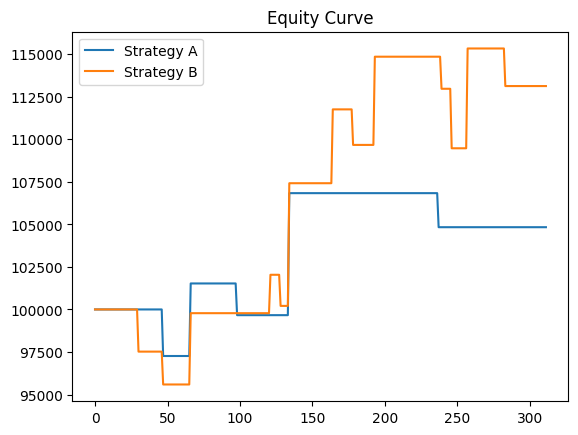

In [16]:
import matplotlib.pyplot as plt

plt.plot(equity_A, label="Strategy A")
plt.plot(equity_B, label="Strategy B")

plt.legend()
plt.title("Equity Curve")
plt.show()

In [ ]:
# ======================
# Optuna 最適化
# ======================

!pip install optuna
import optuna
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

def objective(trial):

    # --- パラメータ ---
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
    }

    threshold = trial.suggest_float('threshold', 0.5, 0.7)

    # --- 時系列CV ---
    tscv = TimeSeriesSplit(n_splits=3)

    scores = []

    for train_idx, val_idx in tscv.split(X):

        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # --- SMOTE（ここ超重要） ---
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

        # --- モデル ---
        model = XGBClassifier(
            **params,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )

        model.fit(X_train_res, y_train_res)

        # --- 予測 ---
        proba = model.predict_proba(X_val_cv)[:, 1]

        # --- 戦略 ---
        signals = (proba > threshold).astype(int)

        # --- シンプル評価（精度ベース） ---
        from sklearn.metrics import f1_score
        score = f1_score(y_val_cv, signals)

        scores.append(score)

    return sum(scores) / len(scores)

# 実行
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.5 MB/s eta 0:00:00


[I 2026-04-24 17:06:12,126] A new study created in memory with name: no-name-cbb774e6-56cc-4b3b-9300-c6c331d195da
[I 2026-04-24 17:06:14,024] Trial 0 finished with value: 0.33474170530222297 and parameters: {'n_estimators': 367, 'max_depth': 6, 'learning_rate': 0.01369223672932467, 'subsample': 0.9380286849903685, 'colsample_bytree': 0.6140724473532768, 'gamma': 0.21286369122530396, 'reg_alpha': 0.44637410251912435, 'reg_lambda': 0.9981321871248736, 'threshold': 0.6571922819948466}. Best is trial 0 with value: 0.33474170530222297.
[I 2026-04-24 17:06:15,240] Trial 1 finished with value: 0.505604525388698 and parameters: {'n_estimators': 307, 'max_depth': 9, 'learning_rate': 0.16516797865691413, 'subsample': 0.6991920036246737, 'colsample_bytree': 0.7579286575866884, 'gamma': 0.30291577822383736, 'reg_alpha': 0.2315413946125277, 'reg_lambda': 1.8456471708557143, 'threshold': 0.6704681008919084}. Best is trial 1 with value: 0.505604525388698.
[I 2026-04-24 17:06:16,529] Trial 2 finished 

In [ ]:
# ======================
# 最終モデル + 最終バックテスト
# ======================

from xgboost import XGBClassifier

# --- Optunaの最適パラメータ取得 ---
best_params = study.best_params.copy()

# thresholdは別で使う
best_threshold = best_params.pop('threshold')

print("Best threshold:", best_threshold)
print("Best model params:", best_params)

# ======================
# モデル再学習（全訓練データ）
# ======================

# SMOTE（訓練データのみ）
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# モデル作成
final_model = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# 学習
final_model.fit(X_train_resampled, y_train_resampled)

# ======================
# 予測
# ======================

proba_final = final_model.predict_proba(X_test)[:, 1]

# ======================
# 戦略（最適threshold）
# ======================

strategy_final = (proba_final > best_threshold).astype(int)

# Series化（重要）
signals_final = pd.Series(strategy_final, index=X_test.index)

# ======================
# バックテスト
# ======================

results_final, equity_final = run_backtest(df, X_test, signals_final)

# ======================
# 結果表示
# ======================

print("===== FINAL RESULT =====")
for k, v in results_final.items():
    print(f"{k}: {v}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(equity_final)
plt.title("Final Strategy Equity Curve")
plt.show()

In [ ]:
# ======================
# 時系列CVで最終戦略を検証
# ======================

from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} =====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # --- SMOTE（訓練データのみ） ---
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # --- モデル（Optunaの最適パラメータ） ---
    model = XGBClassifier(
        **best_params,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res, y_train_res)

    # --- 予測 ---
    proba = model.predict_proba(X_test_cv)[:, 1]

    # --- 戦略 ---
    strategy = (proba > best_threshold).astype(int)
    signals = pd.Series(strategy, index=X_test_cv.index)

    # --- バックテスト ---
    results, equity = run_backtest(df, X_test_cv, signals)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)

# ======================
# 結果まとめ
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY =====")
print(df_results.mean())
print("\nSTD:")
print(df_results.std())